## Выбор модели

На Hugging рассмотрены несколько BERT-подобных русскоязычных моделей:

- `DeepPavlov/rubert-base-cased` — полный RuBERT;
- `cointegrated/rubert-tiny` — компактная версия;
- `cointegrated/rubert-tiny2` — обновлённый компактный русскоязычный BERT.

Для работы выбран `cointegrated/rubert-tiny2`, потому что он заметно легче полного и проще для обучения в коллабе.

## Датасет

DatasetsEval/RusLang-edu-1000 содержит 1000 русскоязычных образовательных вопросов по русскому языку и лингвистике.

Поле `category` содержит 10 классов:

- phonetics_orthoepy;
- orthography;
- morphology;
- syntax;
- punctuation;
- lexicology;
- stylistics;
- history_of_language;
- dialects_variants;
- theoretical_linguistics.

На вход классификатору задаем поле `input`, а `category` используем как целевой класс.

## Установка

In [1]:
%pip install -q -U transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.1 MB/s eta 0:00:00


## Импорты

In [2]:
#===
# Импорты

import random

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset, Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


print(
    "PyTorch:",
    torch.__version__,
)

print(
    "CUDA доступна:",
    torch.cuda.is_available(),
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

PyTorch: 2.11.0+cu128
CUDA доступна: True
GPU: Tesla T4


## Загрузка данных

In [3]:
#===
# Загрузка датасета

DATASET_NAME = "DatasetsEval/RusLang-edu-1000"

dataset = load_dataset(
    DATASET_NAME,
    split="train",
)

print(dataset)
print()
print(dataset.column_names)

README.md:   0%|          | 0.00/10.1k [00:00<?, ?B/s]

ruslang_edu_1000.jsonl:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'instruction', 'input', 'output', 'answer_short', 'explanation', 'task_type', 'category', 'subcategory', 'difficulty', 'level_cefr', 'register', 'dialect_region', 'rule_tags', 'skills', 'certainty', 'split', 'source', 'license', 'gold_unique', 'meta'],
    num_rows: 1000
})

['id', 'instruction', 'input', 'output', 'answer_short', 'explanation', 'task_type', 'category', 'subcategory', 'difficulty', 'level_cefr', 'register', 'dialect_region', 'rule_tags', 'skills', 'certainty', 'split', 'source', 'license', 'gold_unique', 'meta']


## Проверка данных

In [4]:
#===
# Проверка датасета

df = dataset.to_pandas()

print(
    "Строк:",
    len(df),
)

print(
    "Категорий:",
    df["category"].nunique(),
)

print()

print(
    df["category"]
    .value_counts()
)

display(
    df[
        [
            "input",
            "category",
        ]
    ].head(10)
)

Строк: 1000
Категорий: 10

category
syntax                     150
orthography                100
stylistics                 100
morphology                 100
punctuation                100
lexicology                 100
dialects_variants          100
history_of_language        100
theoretical_linguistics    100
phonetics_orthoepy          50
Name: count, dtype: int64


,input,category
0,Сколько букв в русском алфавите?,phonetics_orthoepy
1,Сколько гласных звуков в русском языке?,phonetics_orthoepy
2,Сколько согласных звуков в русском языке?,phonetics_orthoepy
3,Какие буквы не обозначают звуков?,phonetics_orthoepy
4,Что такое слог?,phonetics_orthoepy
5,Как определить количество слогов в слове?,phonetics_orthoepy
6,Какие гласные называют ударными?,phonetics_orthoepy
7,Какие гласные называют безударными?,phonetics_orthoepy
8,Что такое звонкие согласные?,phonetics_orthoepy
9,Что такое глухие согласные?,phonetics_orthoepy


## Кодирование классов

In [5]:
#===
# Классы

label_names = sorted(
    df[
        "category"
    ].unique()
)

label2id = {
    label: index
    for index, label
    in enumerate(
        label_names
    )
}

id2label = {
    index: label
    for label, index
    in label2id.items()
}


df = df[
    [
        "input",
        "category",
    ]
].copy()


df = df.rename(
    columns={
        "input": "text",
    }
)


df["labels"] = (
    df["category"]
    .map(
        label2id
    )
    .astype(int)
)


print(
    "Число классов:",
    len(label_names),
)

print()

for index, label in id2label.items():
    print(
        index,
        "->",
        label,
    )

Число классов: 10

0 -> dialects_variants
1 -> history_of_language
2 -> lexicology
3 -> morphology
4 -> orthography
5 -> phonetics_orthoepy
6 -> punctuation
7 -> stylistics
8 -> syntax
9 -> theoretical_linguistics


## Train / Validation / Test

In [6]:
#===
# Разделение данных

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["labels"],
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["labels"],
)


train_df = train_df.reset_index(
    drop=True
)

val_df = val_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)


print(
    "TRAIN:",
    len(train_df),
)

print(
    "VAL:",
    len(val_df),
)

print(
    "TEST:",
    len(test_df),
)

TRAIN: 800
VAL: 100
TEST: 100


## Токенизация

In [7]:
#===
# Токенизатор

MODEL_NAME = "cointegrated/rubert-tiny2"

MAX_LENGTH = 192


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


print(
    "Модель:",
    MODEL_NAME,
)

print(
    "Размер словаря:",
    tokenizer.vocab_size,
)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Модель: cointegrated/rubert-tiny2
Размер словаря: 83828


In [8]:
#===
# Pandas -> Hugging Face Dataset

train_ds = Dataset.from_pandas(
    train_df[
        [
            "text",
            "labels",
        ]
    ],
    preserve_index=False,
)

val_ds = Dataset.from_pandas(
    val_df[
        [
            "text",
            "labels",
        ]
    ],
    preserve_index=False,
)

test_ds = Dataset.from_pandas(
    test_df[
        [
            "text",
            "labels",
        ]
    ],
    preserve_index=False,
)

In [9]:
#===
# Текст -> токены

def tokenize_batch(
    batch,
):
    return tokenizer(
        batch[
            "text"
        ],
        truncation=True,
        max_length=MAX_LENGTH,
    )


train_tokenized = train_ds.map(
    tokenize_batch,
    batched=True,
    remove_columns=[
        "text",
    ],
)

val_tokenized = val_ds.map(
    tokenize_batch,
    batched=True,
    remove_columns=[
        "text",
    ],
)

test_tokenized = test_ds.map(
    tokenize_batch,
    batched=True,
    remove_columns=[
        "text",
    ],
)


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)


print(
    train_tokenized[0]
)

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

{'labels': 6, 'input_ids': [2, 24499, 23248, 64942, 35, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}


## Модель

In [10]:
#===
# BERT + классификационная голова

model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,

        num_labels=len(
            label_names
        ),

        id2label=id2label,

        label2id=label2id,
    )
)


print(
    "Модель загружена"
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  118MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена


## Метрики

In [11]:
#===
# Метрики

def compute_metrics(
    eval_prediction,
):
    logits, labels = (
        eval_prediction
    )

    predictions = np.argmax(
        logits,
        axis=-1,
    )

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    f1_macro = f1_score(
        labels,
        predictions,
        average="macro",
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
    }

## Fine-tuning

In [12]:
#===
# Параметры обучения

training_args = TrainingArguments(
    output_dir=(
        "/content/"
        "rubert_education_classifier"
    ),

    num_train_epochs=8,

    learning_rate=3e-5,

    weight_decay=0.01,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model=(
        "f1_macro"
    ),

    greater_is_better=True,

    save_total_limit=1,

    logging_steps=10,

    report_to="none",

    seed=SEED,

    fp16=torch.cuda.is_available(),
)

In [13]:
#===
# Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=(
        train_tokenized
    ),

    eval_dataset=(
        val_tokenized
    ),

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=(
        compute_metrics
    ),

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
)

In [14]:
#===
# Обучение

train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.217877,2.182529,0.330000,0.246486
2,2.035754,1.967881,0.480000,0.370435
3,1.910516,1.769141,0.590000,0.506093
4,1.742117,1.608149,0.660000,0.591844
5,1.557251,1.496821,0.690000,0.622798
6,1.551694,1.424907,0.710000,0.669501
7,1.455469,1.384526,0.740000,0.704944
8,1.465179,1.371978,0.740000,0.701358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Оценка на test

In [15]:
#===
# Test

test_metrics = trainer.evaluate(
    test_tokenized
)

print(
    test_metrics
)

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
1.465179,1.469165,8,0.670000,0.620773


{'eval_loss': 1.4691650867462158, 'eval_accuracy': 0.67, 'eval_f1_macro': 0.620773172381868}


## Отчёт по классам

In [16]:
#===
# Предсказания test

prediction_output = trainer.predict(
    test_tokenized
)

logits = (
    prediction_output.predictions
)

true_ids = (
    prediction_output.label_ids
)

pred_ids = np.argmax(
    logits,
    axis=-1,
)


print(
    classification_report(
        true_ids,
        pred_ids,
        labels=list(
            range(
                len(label_names)
            )
        ),
        target_names=label_names,
        digits=3,
        zero_division=0,
    )
)

                         precision    recall  f1-score   support

      dialects_variants      0.467     0.700     0.560        10
    history_of_language      0.600     0.300     0.400        10
             lexicology      0.400     0.200     0.267        10
             morphology      0.692     0.900     0.783        10
            orthography      0.692     0.900     0.783        10
     phonetics_orthoepy      1.000     0.200     0.333         5
            punctuation      1.000     0.600     0.750        10
             stylistics      0.750     0.600     0.667        10
                 syntax      0.636     0.933     0.757        15
theoretical_linguistics      0.833     1.000     0.909        10

               accuracy                          0.670       100
              macro avg      0.707     0.633     0.621       100
           weighted avg      0.689     0.670     0.642       100



## Матрица ошибок

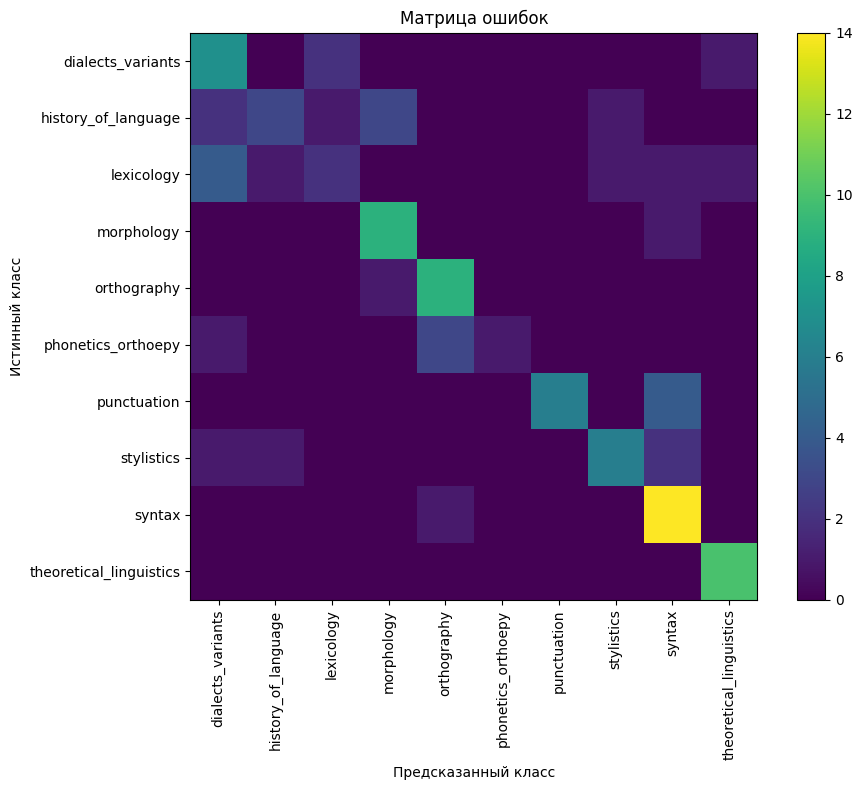

In [17]:
#===
# Confusion matrix

cm = confusion_matrix(
    true_ids,
    pred_ids,
)


fig, ax = plt.subplots(
    figsize=(
        10,
        8,
    )
)

image = ax.imshow(
    cm
)

ax.set_xticks(
    range(
        len(label_names)
    )
)

ax.set_yticks(
    range(
        len(label_names)
    )
)

ax.set_xticklabels(
    label_names,
    rotation=90,
)

ax.set_yticklabels(
    label_names,
)

ax.set_xlabel(
    "Предсказанный класс"
)

ax.set_ylabel(
    "Истинный класс"
)

ax.set_title(
    "Матрица ошибок"
)

fig.colorbar(
    image,
    ax=ax,
)

plt.tight_layout()
plt.show()

## Примеры предсказаний

Выведем **10** для наглядности.

In [18]:
#===
# Вероятности классов

shifted = (
    logits
    - logits.max(
        axis=1,
        keepdims=True,
    )
)

probabilities = np.exp(
    shifted
)

probabilities = (
    probabilities
    / probabilities.sum(
        axis=1,
        keepdims=True,
    )
)


confidence = probabilities.max(
    axis=1
)

In [19]:
#===
# 10 примеров

examples_df = test_df.copy()

examples_df[
    "true_class"
] = [
    id2label[
        int(label_id)
    ]
    for label_id
    in true_ids
]

examples_df[
    "predicted_class"
] = [
    id2label[
        int(label_id)
    ]
    for label_id
    in pred_ids
]

examples_df[
    "confidence"
] = confidence


examples_df[
    "correct"
] = (
    examples_df[
        "true_class"
    ]
    == examples_df[
        "predicted_class"
    ]
)


examples_to_show = (
    examples_df
    .sample(
        n=min(
            10,
            len(
                examples_df
            ),
        ),
        random_state=SEED,
    )
    [
        [
            "text",
            "true_class",
            "predicted_class",
            "confidence",
            "correct",
        ]
    ]
)


display(
    examples_to_show
)

,text,true_class,predicted_class,confidence,correct
83,Что такое побудительное предложение?,syntax,syntax,0.515990,True
53,Приведите примеры дзеканья,dialects_variants,dialects_variants,0.206299,True
70,Что такое стилистическая неуместность?,lexicology,stylistics,0.212582,False
45,Приведите примеры слов с ПРЕ-,orthography,orthography,0.339807,True
44,Приведите примеры гибридных слов,dialects_variants,lexicology,0.204102,False
39,Что такое полилог?,stylistics,history_of_language,0.189184,False
22,Как соединяются однородные члены?,syntax,syntax,0.192392,True
80,Как определить число прилагательного?,orthography,morphology,0.271906,False
10,Как ставятся знаки препинания при обобщающих с...,syntax,orthography,0.247238,False
0,Когда ставится многоточие?,punctuation,punctuation,0.257335,True
